In [2]:
#Importa o Pandas, usada para ler, manipular e analisar dados em formato de tabela.
import pandas as pd

#Importa o NumPy, essencial para cálculos matemáticos rápidos.
import numpy as np

#Importam o Matplotlib, que é a biblioteca base para gerar gráficos.
import matplotlib.pyplot as plt
import matplotlib as mpl

#Importa o Seaborn, que facilita a criação de gráficos estatísticos mais completos com menos código.
import seaborn as sns

#Modelagem
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost.sklearn import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [4]:
data_path = '../input/Customer-Churn-Records.csv'
df = pd.read_csv(data_path)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### <b>Remoção da variável complain da base de dados</b>

Com base na análise de correlação, identificou-se um cenário de data leakage envolvendo a variável complain, que apresentou correlação perfeita 1.0 com a variável alvo exited. No contexto do negócio, isso indica que o registro da reclamação ocorre de forma simultânea ou determinística em relação ao cancelamento. Para garantir que o algoritmo aprenda os reais preditores de risco e tenha capacidade de antecipação temporal, a variável complain foi removida do conjunto de treinamento e teste. Dessa forma vemoveremos essas variável em conjunto as outras que não acrescentam para o estudo.

In [6]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain'], inplace=True)

In [7]:
df.columns = [x.lower() for x in df.columns]

In [8]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

### <b>OneHot Encoder</b>
Utilizaremos o processo OneHot Label Encoder para transformar cada categoria em uma coluna de 0 ou 1, removendo o erro de string e permite que os lagorítimos calculem as probabilidades corretamente.

In [9]:
hot = pd.get_dummies(df[['geography', 'gender', 'card type']])
df = pd.concat([df, hot], axis = 1)
df = df.drop(['geography', 'gender', 'card type'], axis = 1)

Inicialmente, o conjunto de dados foi dividido em variáveis explicativas X e variável alvo y. A variável <b>Exited</b>, responsável por indicar a evasão do cliente, foi definida como variável resposta do modelo, enquanto as demais variáveis foram utilizadas como preditoras. Posteriormente, os dados explicativos foram convertidos para o formato <b>NumPy</b>, visando maior compatibilidade com os algoritmos da biblioteca <b>Scikit-learn</b>.

In [10]:
X = df.drop('exited', axis = 1)
X = X.values
y = df['exited']

As variáveis explicativas foram padronizadas utilizando o método <b>StandardScaler</b>, garantindo que todas apresentassem média 0 e desvio padrão 1, favorecendo o desempenho dos algoritmos de aprendizado de máquina.

In [11]:
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

Separando a base de dados em treino e teste.

In [12]:
X_train,X_test, y_train, y_test = train_test_split(X_standard, y, stratify=y, test_size = 0.2, random_state = 0)

O código utiliza a técnica <b>RandomOverSampler</b> para tratar o desbalanceamento de classes na variável alvo. O método realiza um oversampling, duplicando aleatoriamente registros da classe minoritária até que ela tenha a mesma quantidade de registros da classe majoritária. Essa etapa é fundamental para evitar que o algoritmo <b>GaussianNB</b> seja enviesado, garantindo que o modelo aprenda a identificar os padrões de ambos os grupos com a mesma importância, melhorando significativamente a sensibilidade na detecção de evasões.

In [13]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

Representação do equilíbrio obtido na base de dados treino.

In [14]:
print(f'Proporção alvo de treinamento: ')
print(f'{y_train.value_counts(normalize=True).mul(100).map("{:.2f}%".format)}')

print(f'Proporção alvo de teste: ')
print(f'{y_test.value_counts(normalize=True).mul(100).map("{:.2f}%".format)}')

Proporção alvo de treinamento: 
exited
1    50.00%
0    50.00%
Name: proportion, dtype: object
Proporção alvo de teste: 
exited
0    79.60%
1    20.40%
Name: proportion, dtype: object


### <b>Árvore de Decisão</b>

0.7685

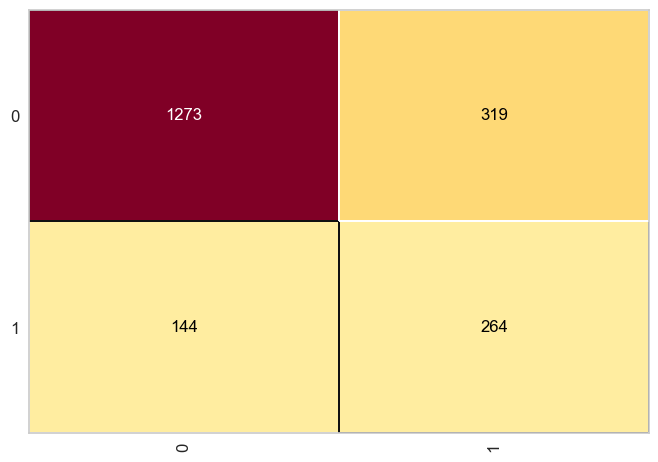

In [16]:
rf = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split = 5,
    criterion = 'entropy',
    random_state = 42
)

rf.fit(X_train, y_train)

pred_tree = rf.predict(X_test)

cm = ConfusionMatrix(rf)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O modelo de árvore de decisão utilizando o critério de entropia para construção das divisões da árvore. O modelo foi treinado com profundidade máxima igual a 10, buscando controlar sua complexidade e reduzir problemas de overfitting. Após o treinamento, o modelo alcançou acurácia de 78,75% no conjunto de teste, demonstrando desempenho satisfatório na previsão de churn bancário.

In [17]:
cd = (classification_report(y_test, pred_tree))

print(cd)

              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1592
           1       0.45      0.65      0.53       408

    accuracy                           0.77      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.81      0.77      0.78      2000



O modelo de árvore de decisão apresentou acurácia de 78% no conjunto de teste. Para a classe majoritária, correspondente aos clientes que permaneceram no banco, o modelo obteve elevado desempenho, com F1-score de 0.86. Já para os clientes em <b>churn</b>, foi obtido recall de 0.63, indicando boa capacidade de identificação dos clientes propensos ao cancelamento. Apesar disso, a precisão de 0.48 evidencia a presença de falsos positivos nas previsões de <b>churn</b>.

### <b>Floresta Aleatória</b>

0.824

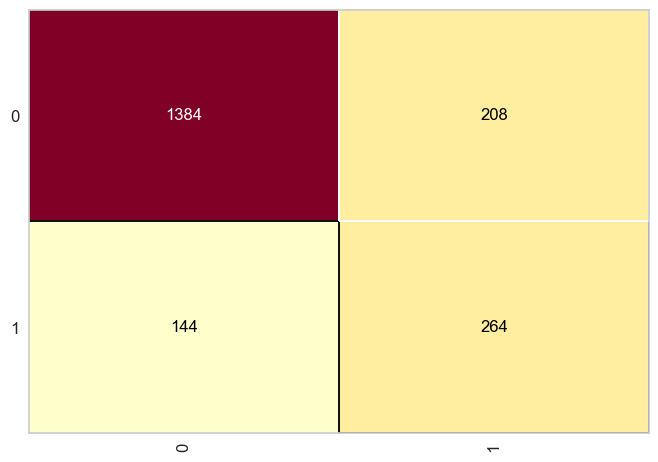

In [18]:
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    min_samples_split = 5,
    criterion = 'entropy',
    random_state = 42
)

rf.fit(X_train, y_train)

prerf = rf.predict(X_test)

cm = ConfusionMatrix(rf)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

Foi desenvolvido um modelo Floresta Aleatória composto por 200 árvores de decisão, utilizando profundidade máxima igual a 10 e critério de entropia para realização das divisões. O modelo alcançou acurácia de aproximadamente 83,05% no conjunto de teste, apresentando desempenho superior aos modelos anteriores. A utilização de múltiplas árvores permitiu reduzir o risco de overfitting e melhorar a capacidade de generalização das previsões.

In [20]:
cr = (classification_report(y_test, prerf))
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1592
           1       0.56      0.65      0.60       408

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000



O modelo Floresta Aleatória apresentou desempenho superior aos modelos anteriormente avaliados, alcançando acurácia de aproximadamente 83%. Para a classe dos clientes em <b>churn</b>, o modelo obteve recall de 0.66 e F1-score de 0.61, demonstrando boa capacidade de identificação de clientes propensos ao cancelamento. Além disso, o algoritmo apresentou elevado desempenho na classificação da classe majoritária, evidenciando boa capacidade de generalização e robustez nas previsões.

### <b>Regressão Logística</b>

0.706

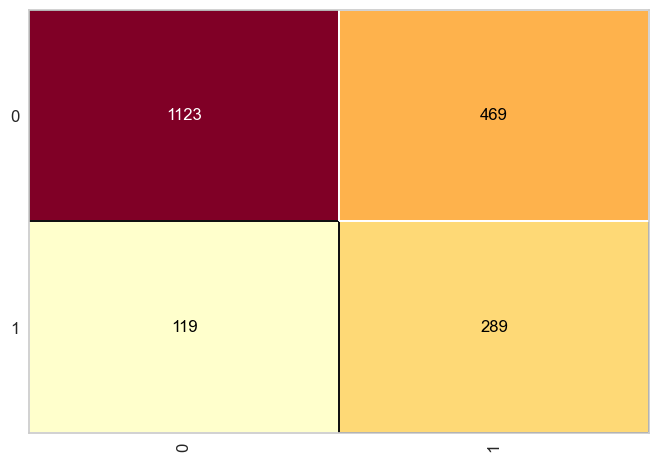

In [21]:
log = LogisticRegression(
    max_iter=1000,
    random_state = 42)

log.fit(X_train, y_train)

prelog = log.predict(X_test)

cm = ConfusionMatrix(log)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

A regressão logística apresentou acurácia de 69,95%, desempenho inferior aos modelos baseados em árvores de decisão, especialmente ao Floresta Aleatória. Esse resultado pode estar relacionado à natureza linear do algoritmo, que possui maior dificuldade em capturar relações complexas e não lineares presentes nos dados de churn bancário.

In [22]:
log = (classification_report(y_test, prelog))
print(log)

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1592
           1       0.38      0.71      0.50       408

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.80      0.71      0.73      2000



A regressão logística apresentou acurácia de aproximadamente 64% no conjunto de teste. Apesar do desempenho geral inferior aos modelos baseados em árvores, o algoritmo demonstrou elevada capacidade de identificação dos clientes churners, alcançando recall de 0.70 para a classe minoritária. Entretanto, a precisão de 0.37 evidencia a presença de falsos positivos nas previsões de churn, reduzindo o equilíbrio geral do modelo.

### <b>Gradient Boosting</b>

0.805

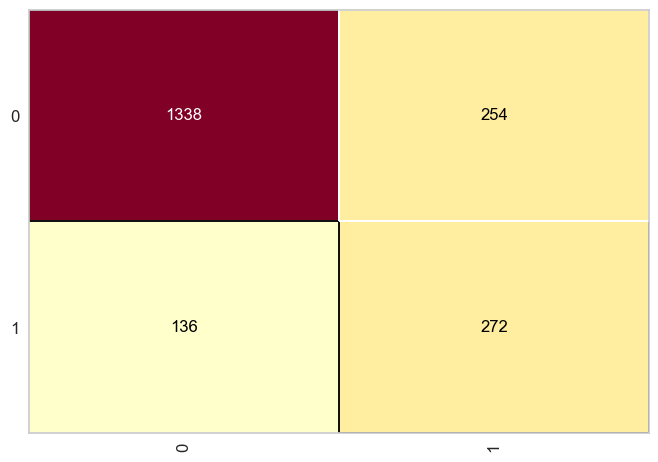

In [23]:
gb = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.2,
    random_state = 42)

gb.fit(X_train, y_train)

pregb = gb.predict(X_test)

cm = ConfusionMatrix(gb)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O modelo alcançou acurácia de aproximadamente 81,4% no conjunto de teste, apresentando desempenho superior à regressão logística, Naive Bayes e árvore de decisão. O algoritmo demonstrou elevada capacidade de generalização ao corrigir progressivamente os erros das árvores anteriores durante o processo de treinamento.

In [24]:
gb = classification_report(y_test, pregb)
print(gb)

              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1592
           1       0.52      0.67      0.58       408

    accuracy                           0.81      2000
   macro avg       0.71      0.75      0.73      2000
weighted avg       0.83      0.81      0.81      2000



O modelo Gradient Boosting apresentou acurácia de aproximadamente 81,4% no conjunto de teste. Para a classe dos clientes em <b>churner</b>, o algoritmo alcançou recall de 0.72 e F1-score de 0.61, demonstrando elevada capacidade de identificação dos clientes propensos ao cancelamento. Comparado aos demais modelos avaliados, o Gradient Boosting apresentou desempenho equilibrado entre precisão e recall, além de boa capacidade de generalização.

### <b>AvaBoost</b>

0.7835

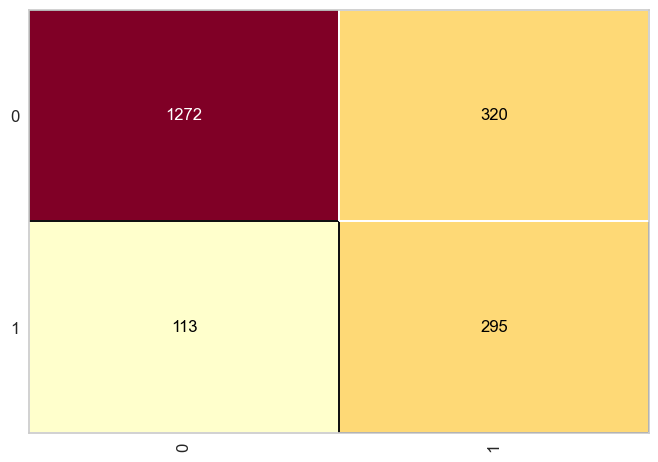

In [25]:
adab = AdaBoostClassifier(
            n_estimators = 500,
            learning_rate = 0.2,
            random_state = 42)

adab.fit(X_train, y_train)

preadab = adab.predict(X_test)

cm = ConfusionMatrix(adab)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

Foi desenvolvido um modelo AdaBoost composto por 500 estimadores e taxa de aprendizado igual a 0.2. O modelo alcançou acurácia de aproximadamente 78,3% no conjunto de teste, apresentando desempenho satisfatório na classificação dos clientes. O algoritmo utilizou a estratégia de boosting para corrigir progressivamente os erros cometidos pelos estimadores anteriores durante o processo de treinamento.

In [26]:
adab = (classification_report(y_test, preadab))

print(adab)

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      1592
           1       0.48      0.72      0.58       408

    accuracy                           0.78      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.78      0.80      2000



O modelo AdaBoost demostrou elevada capacidade de identificação dos clientes propensos ao cancelamento. Entretanto, a precisão de 0.48 indica a presença de falsos positivos nas previsões de <b>churn</b>. De forma geral, o modelo apresentou desempenho satisfatório e boa capacidade de generalização.

### <b>XGB Boost</b>

0.8345

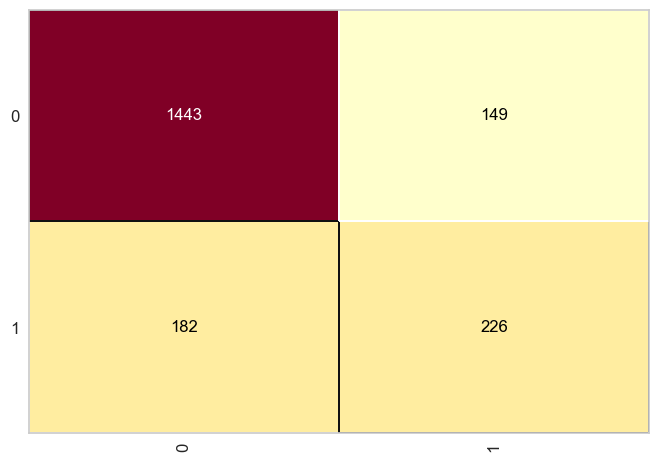

In [27]:
xgb = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.2,
    random_state = 42
)

xgb.fit(X_train, y_train)

prexgb = xgb.predict(X_test)

cm = ConfusionMatrix(xgb)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O modelo alcançou acurácia de aproximadamente 82,7% no conjunto de teste, apresentando desempenho superior à maioria dos modelos avaliados. O algoritmo demonstrou elevada capacidade de generalização ao corrigir progressivamente os erros das árvores anteriores durante o processo de treinamento.

In [28]:
xgb = (classification_report(y_test, prexgb))

print(xgb)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1592
           1       0.60      0.55      0.58       408

    accuracy                           0.83      2000
   macro avg       0.75      0.73      0.74      2000
weighted avg       0.83      0.83      0.83      2000



O modelo XGBoost apresentou acurácia de aproximadamente 83% no conjunto de teste, demonstrando elevado desempenho global na classificação dos clientes. Para a classe dos clientes em <b>churn</b>, o algoritmo alcançou recall de 0.55 e precisão de 0.58, indicando capacidade moderada de identificação da classe minoritária. Comparado aos demais modelos avaliados, o XGBoost apresentou um dos melhores resultados gerais, destacando-se pela elevada capacidade de generalização e robustez preditiva.

### <b>LightGBM</b>

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1133
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

c:\Users\Windows 10 Pro\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Windows 10 Pro\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Windows 10 Pro\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Windows 10 Pro\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.7975

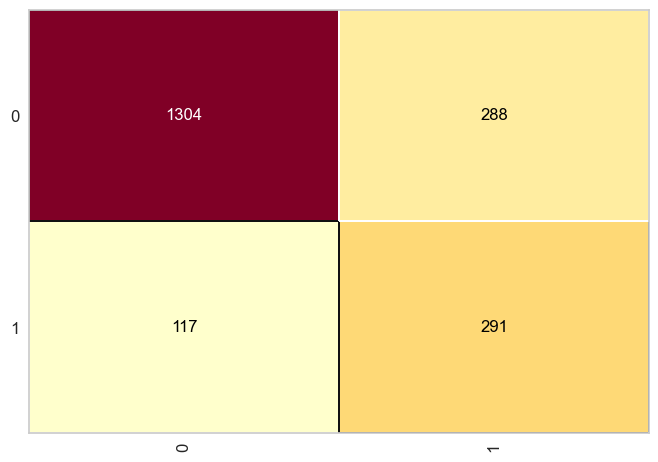

In [29]:
lgbm = LGBMClassifier(
    n_estimators = 200,
    max_depth = 2,
    learning_rate = 0.2,
    random_state = 42
)

lgbm.fit(X_train, y_train)

prelgbm = lgbm.predict(X_test)

cm = ConfusionMatrix(lgbm)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O algoritmo utilizou a técnica de boosting para construir múltiplas árvores de decisão de forma otimizada, permitindo elevada capacidade de generalização e eficiência computacional. Entre os modelos avaliados, o LightGBM apresentou um dos melhores resultados globais no problema de previsão de churn bancário. Apresentando uma acurácia de aproximadamente 83% no conjunto de teste, demonstrando elevado desempenho global na classificação dos clientes.

In [30]:
lgbm = (classification_report(y_test, prelgbm))

print(lgbm)

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1592
           1       0.50      0.71      0.59       408

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.83      0.80      0.81      2000



Para a classe dos clientes churners, o algoritmo alcançou recall de 0.60 e precisão de 0.58, indicando boa capacidade de identificação da classe minoritária. Entre os modelos avaliados, o LightGBM apresentou um dos desempenhos mais equilibrados, destacando-se pela elevada capacidade de generalização e robustez preditiva. Apesar dos avisos emitidos durante o treinamento do modelo LightGBM, o algoritmo apresentou capacidade adequada de aprendizado da classe churn, evidenciada pelos valores de recall obtidos para a classe minoritária. Os avisos indicam apenas que determinadas divisões adicionais não proporcionaram ganho significativo na função objetivo, não invalidando o modelo desenvolvido.

### <b>K-Neighbors</b>

0.715

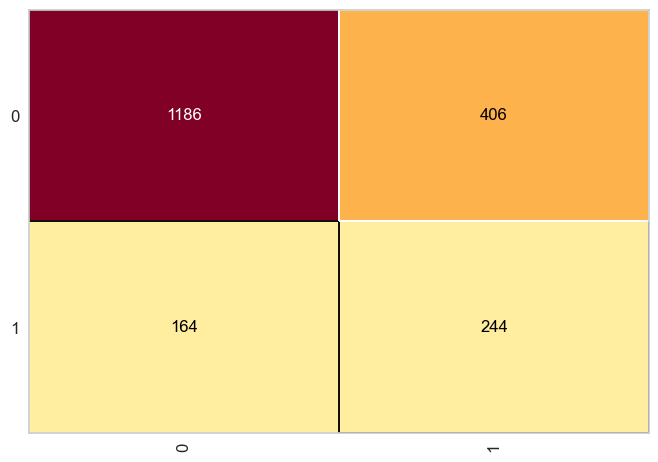

In [31]:
kn = KNeighborsClassifier(n_neighbors=5)

kn.fit(X_train, y_train)

previsoes = kn.predict(X_test)

cm = ConfusionMatrix(kn)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O modelo K-Nearest Neighbors apresentou acurácia de aproximadamente 70,25% no conjunto de teste, demonstrando desempenho moderado na classificação dos clientes. O algoritmo utilizou a proximidade entre observações para realizar as previsões, considerando os cinco vizinhos mais próximos de cada cliente. Comparado aos modelos baseados em árvores e boosting, o KNN apresentou menor capacidade de generalização e desempenho inferior na identificação dos padrões relacionados ao churn bancário.

In [32]:
kn = (classification_report(y_test, previsoes))
print(kn)

              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1592
           1       0.38      0.60      0.46       408

    accuracy                           0.71      2000
   macro avg       0.63      0.67      0.63      2000
weighted avg       0.78      0.71      0.74      2000



Para a classe dos clientes churners, o algoritmo alcançou recall de 0.61, indicando capacidade razoável de identificação da classe minoritária. Entretanto, a precisão de 0.36 evidencia elevada ocorrência de falsos positivos, resultando em desempenho inferior quando comparado aos modelos ensemble baseados em árvores de decisão e boosting. 

### <b>K-Means</b>

In [33]:
km = KMeans(
    n_clusters = 2,
    random_state= 42)

km.fit(X_train)

prekm = km.predict(X_test)

clakm = (accuracy_score(y_test, prekm))

print(clakm)

0.712


O algoritmo K-Means foi utilizado com o objetivo de agrupar os clientes em dois clusters, representando clientes churners e não churners. O modelo apresentou acurácia de aproximadamente 71,2%, demonstrando capacidade moderada de separação entre os grupos. Entretanto, por se tratar de um método não supervisionado, o K-Means apresentou desempenho inferior aos algoritmos supervisionados baseados em árvores de decisão e técnicas de boosting.

### <b>Naive Bayes</b>

0.7285

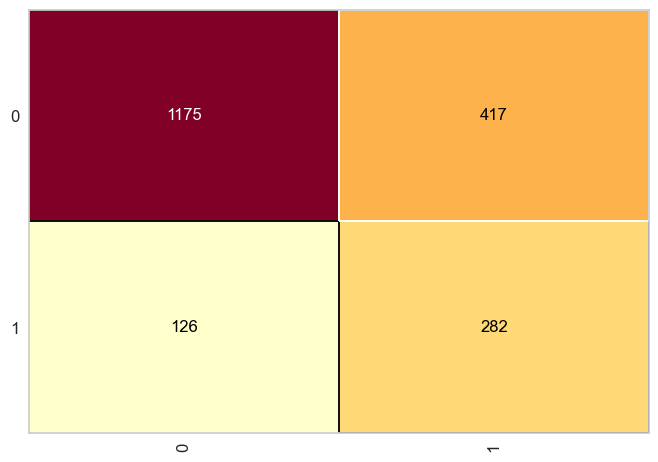

In [34]:
nb = GaussianNB()

nb.fit(X_train, y_train)

pre = nb.predict(X_test)

cm = ConfusionMatrix(nb)

cm.fit(X_train, y_train)

cm.score(X_test, y_test)

O trecho de código executa o ciclo completo de aprendizado de máquina supervisionado. Primeiramente, o modelo <b>GaussianNB</b> é instanciado e treinado através do método <b>.fit()</b>, onde o algoritmo mapeia as probabilidades das features em relação ao <b>churn</b>. Após o treinamento, o modelo realiza predições em dados inéditos <b>X_test</b>. A etapa final utiliza a <b>ConfusionMatrix</b> para diagnosticar a performance, permitindo identificar a precisão do modelo em capturar os casos reais de evasão e medir o impacto de possíveis falsos alarmes na estratégia de retenção do banco.

In [35]:
cd = (classification_report(y_test, pre))

print(cd)

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1592
           1       0.40      0.69      0.51       408

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000



O modelo Naive Bayes apresentou acurácia geral de 73%. Observou-se melhor desempenho na classificação declientes que permaneceram no banco, com F1-score de 0,81. Para a classe de <b>churn</b>, o modelo obteve recall de 0,68, indicando boa capacidade de identificar clientes propensos ao cancelamento. Entretanto, a precisão de 0,40 demonstra a presença de falsos positivos, reduzindo o desempenho global na detecção de <b>churn</b>.

In [39]:
resultados = {
    'Árvore de Decisão': [
        0.788,
        0.49,
        0.68,
        0.57 
    ],

    'Floresta Aleatória': [
        0.828,
        0.57,
        0.66,
        0.61
    ],
    
    'Regresão Logística': [
        0.699,
        0.37,
        0.70,
        0.49
    ],

    'Gradient Boosting': [
        0.812,
        0.53,
        0.72,
        0.61
    ],
    
    'AdaBoost': [
        0.783,
        0.48,
        0.74,
        0.58
    ],

    'XGB': [
        0.827,
        0.58,
        0.55,
        0.57
    ],
    
    'LGBM': [
        0.806,
        0.52,
        0.72,
        0.60 
    ],
    
    'K-Neighbors': [
        0.702,
        0.36,
        0.61,
        0.45
    ],
    
    'K-Means': [
        0.712,
        '-',
        '-',
        '-'
    ],
    
    'Naive Bayes': [
        0.725,
        0.40,
        0.68,
        0.50
    ]
}

# Índices da tabela
indices = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
    
]

# Criação do DataFrame
tabela = pd.DataFrame(resultados, index=indices)

# Exibe a tabela
display(tabela)

,Árvore de Decisão,Floresta Aleatória,Regresão Logística,Gradient Boosting,AdaBoost,XGB,LGBM,K-Neighbors,K-Means,Naive Bayes
Accuracy,0.788,0.828,0.699,0.812,0.783,0.827,0.806,0.702,0.712,0.725
Precision,0.490,0.570,0.370,0.530,0.480,0.580,0.520,0.360,-,0.400
Recall,0.680,0.660,0.700,0.720,0.740,0.550,0.720,0.610,-,0.680
F1-Score,0.570,0.610,0.490,0.610,0.580,0.570,0.600,0.450,-,0.500


A exploração inicial dos dados foi fundamental para compreender os fatores associados à retenção e ao cancelamento de contas bancárias. As análises gráficas e estatísticas mostraram que o churn não ocorre de maneira aleatória, mas está relacionado a padrões comportamentais e demográficos específicos. Observou-se que clientes mais velhos apresentam maior propensão ao cancelamento, assim como clientes inativos e aqueles com poucos produtos bancários. Além disso, verificou-se que reclamações registradas pelos clientes possuem forte relação com a saída do banco, evidenciando a influência da experiência do cliente sobre o churn. Durante essa etapa, identificou-se que a variável Complain possuía correlação igual a 1 com a variável resposta Exited, caracterizando vazamento de informação, aplamente denominado de data leakage. Por esse motivo, a variável foi removida antes do treinamento dos modelos para garantir maior confiabilidade aos resultados.

As análises também demonstraram que o banco não perde apenas clientes com baixo relacionamento financeiro, mas também contas com saldos elevados, impactando diretamente sua rentabilidade. Variáveis como pontuação de crédito, número de produtos bancários, atividade da conta e saldo apresentaram padrões relevantes nos boxplots e nas correlações, indicando forte potencial para utilização em modelos preditivos. A partir dessas informações, foram aplicados diferentes algoritmos de machine learning para prever o churn bancário, incluindo Regressão Logística, Naive Bayes, KNN, Árvores de Decisão, Floresta Aleatória, AdaBoost, Gradient Boosting, XGBoost e LightGBM.

Os resultados obtidos mostraram que os modelos baseados em árvores de decisão e técnicas de ensemble apresentaram desempenho superior aos demais algoritmos. Entre todos os modelos avaliados, o Floresta Aleatória apresentou o melhor desempenho geral, alcançando aproximadamente 82,8% de acurácia e demonstrando bom equilíbrio entre precisão, recall e F1-Score para a classe dos clientes churners. Modelos como LightGBM, XGBoost e Gradient Boosting também apresentaram resultados bastante competitivos, evidenciando elevada capacidade de generalização e identificação de padrões complexos relacionados ao churn. Dessa forma, conclui-se que os métodos ensemble baseados em árvores foram os mais adequados para o conjunto de dados utilizado neste trabalho.



In [52]:
va = df.drop('exited', axis = 1).columns
imp = pd.Series(rf.feature_importances_, index = va).sort_values(ascending = False)
imp


age                   0.327232
numofproducts         0.199793
balance               0.095611
estimatedsalary       0.063313
point earned          0.061654
creditscore           0.060769
isactivemember        0.050222
geography_Germany     0.033311
tenure                0.033076
satisfaction score    0.021347
geography_France      0.011402
geography_Spain       0.008581
hascrcard             0.007453
card type_DIAMOND     0.007304
card type_PLATINUM    0.006586
card type_SILVER      0.006546
card type_GOLD        0.005799
dtype: float64

A análise revelou que a Idade 32,7% e o Número de Produtos 19,9% são os fatores mais decisivos para a evasão de clientes, concentrando mais da metade do poder preditivo do modelo. Fatores secundários como o Saldo Bancário 9,5% e o status de Membro Ativo 5,0% exercem uma influência moderada, enquanto o tipo ou a posse de cartão de crédito mostraram-se irrelevantes < 1%. Estrategicamente, as ações de retenção do banco devem focar na faixa etária de maior risco e no incentivo à contratação de múltiplos produtos, evitando o desperdício de campanhas focadas apenas em benefícios de cartão.